01. Environment Check
Python  : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
OS      : Windows 10
PyTorch : 2.6.0+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Ti
02. Package installation complete.
03. All libraries imported successfully.
04. Configuration set.
05. Loading saved prediction CSVs ...
    Loaded: vgg16_rgb (54,000 samples)
    Loaded: vgg16_rgb_fft (54,000 samples)
    Loaded: vgg16_rgb_fft_phy (54,000 samples)
    Loaded: xcep_rgb (54,000 samples)
    Loaded: xcep_rgb_fft (54,000 samples)
    Loaded: xcep_rgb_fft_phy (54,000 samples)
    Total loaded: 6 / 6 experiments
06. Reloading best models from checkpoints ...
    Loaded: vgg16_rgb
    Loaded: vgg16_rgb_fft
    Loaded: vgg16_rgb_fft_phy
    Loaded: xcep_rgb
    Loaded: xcep_rgb_fft
    Loaded: xcep_rgb_fft_phy
    Models loaded: 6 / 6
07. Test DataLoader ready — 54,000 samples
08. Computing full metrics for all models ...
            Model  Accuracy    AUC

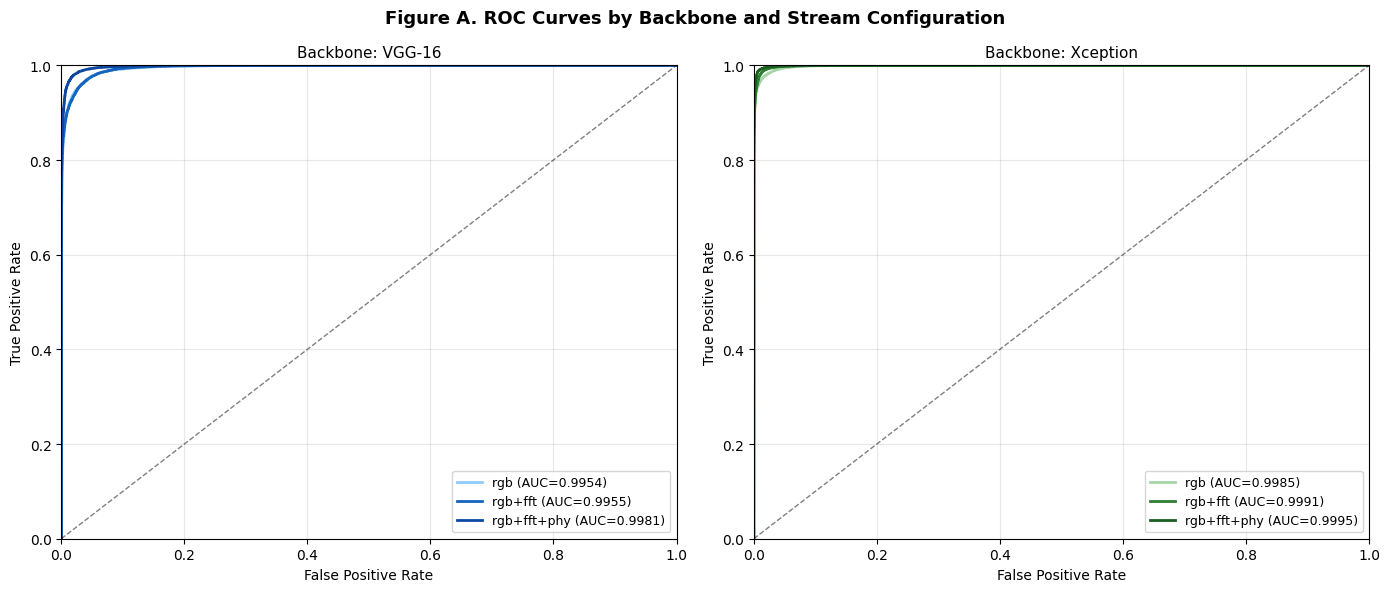

    Saved → eda_outputs/FigA_roc_curves.png
10. Figure B: Precision-Recall Curves ...


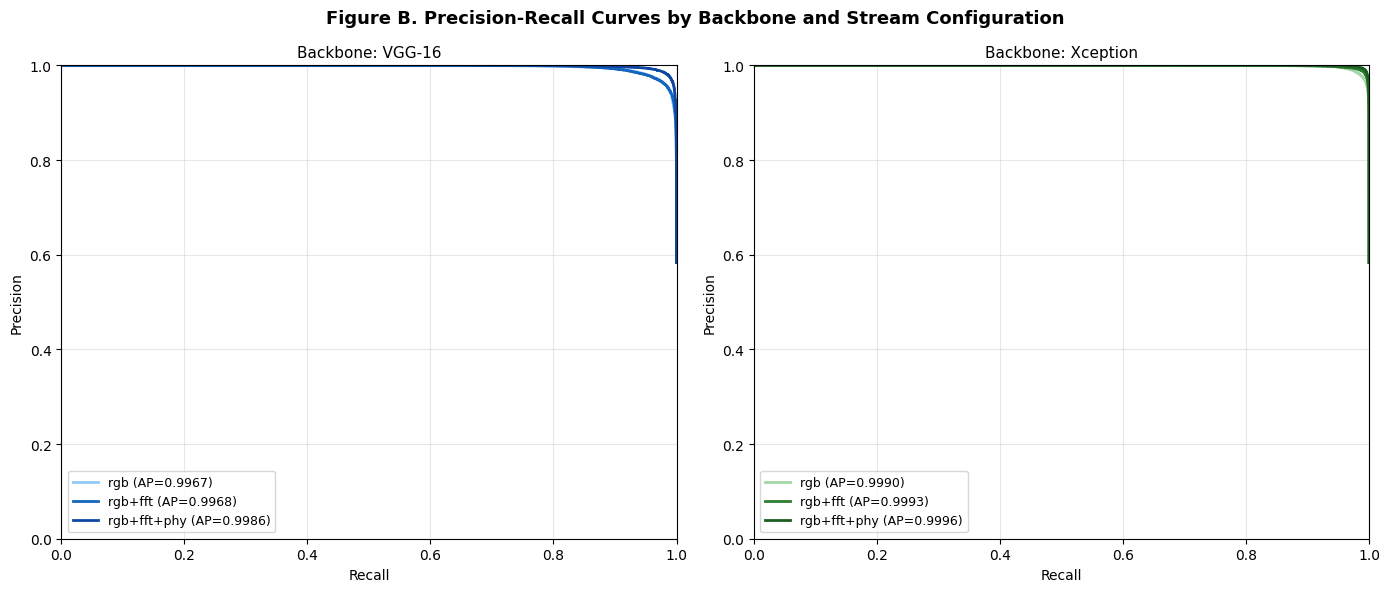

    Saved → eda_outputs/FigB_pr_curves.png
11. Figure C: Confusion Matrices ...


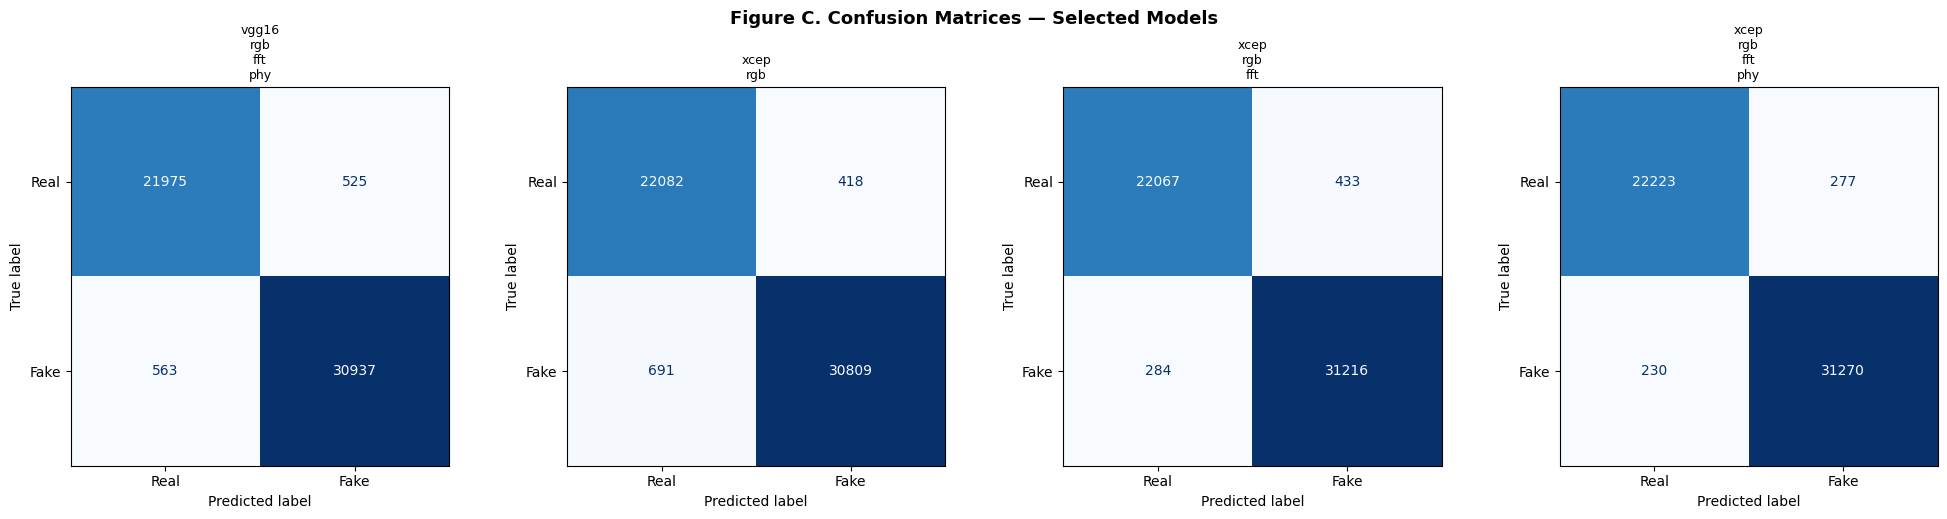

    Saved → eda_outputs/FigC_confusion_matrices.png
12. Figure D: Ablation Study Bar Chart ...


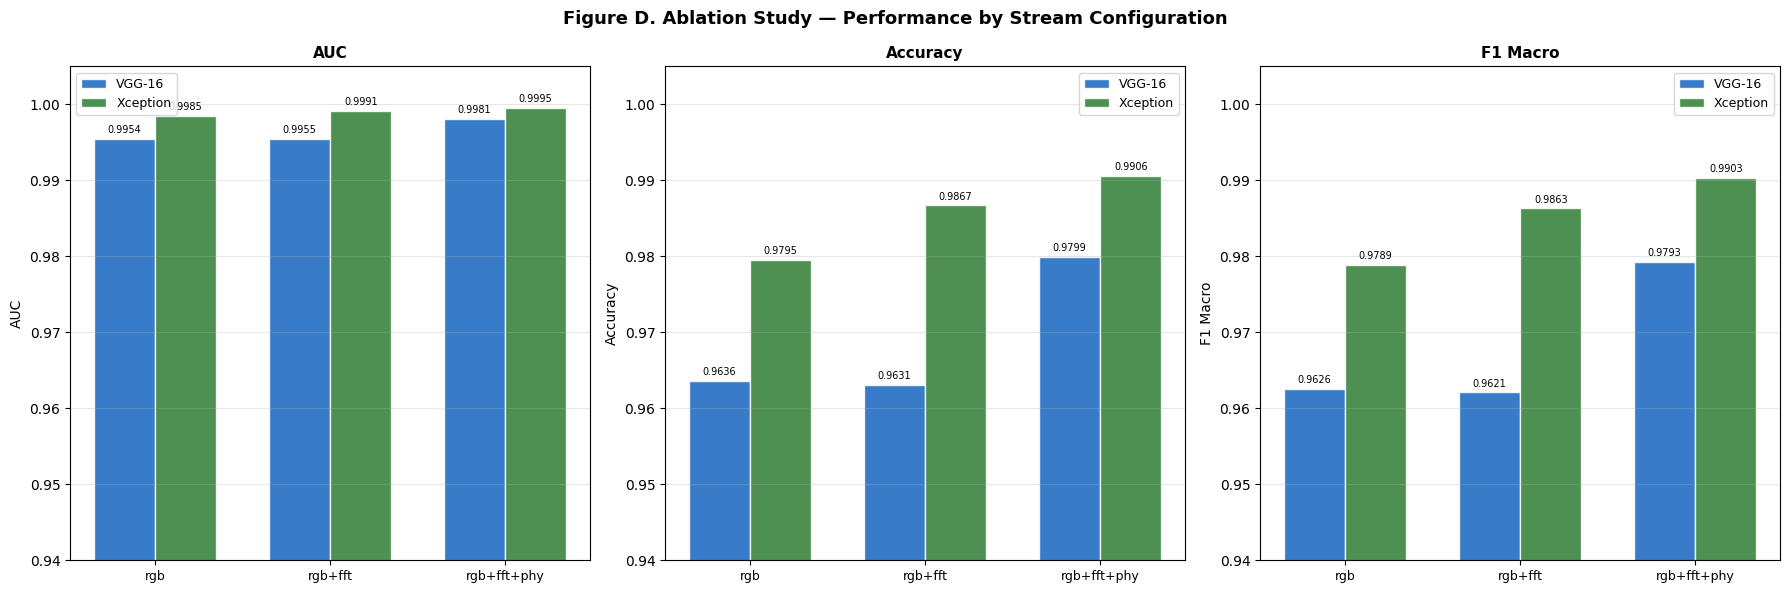

    Saved → eda_outputs/FigD_ablation_bar.png
13. Figure E: Training Curves for Best Model ...


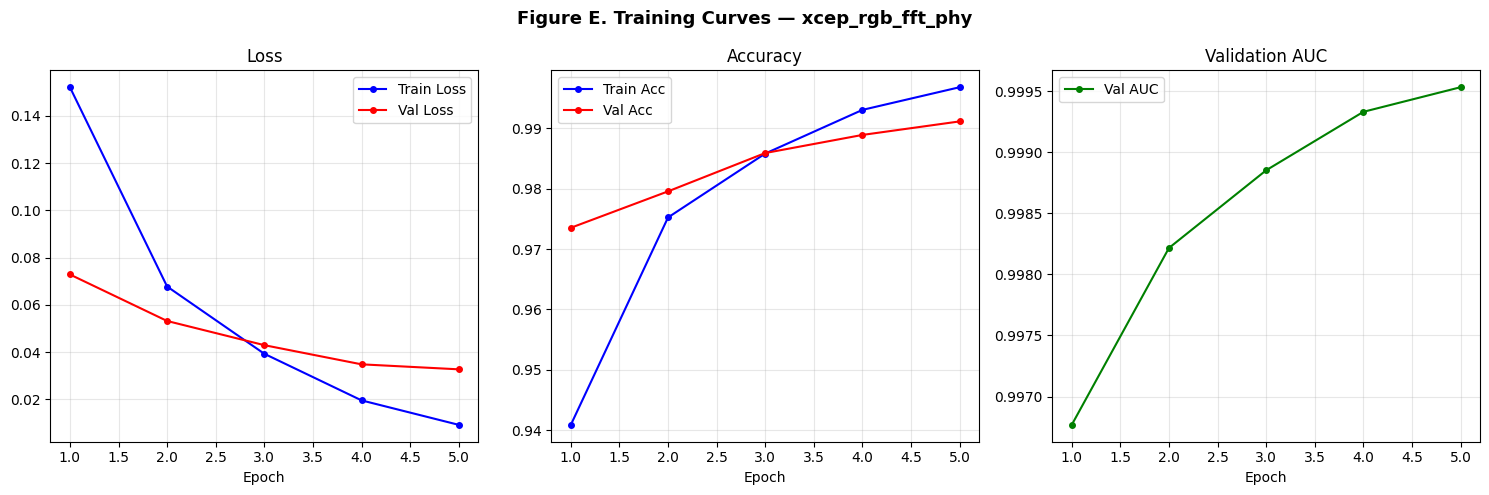

    Saved → eda_outputs/FigE_training_curves_best.png
14. Figure F: Score Distribution ...


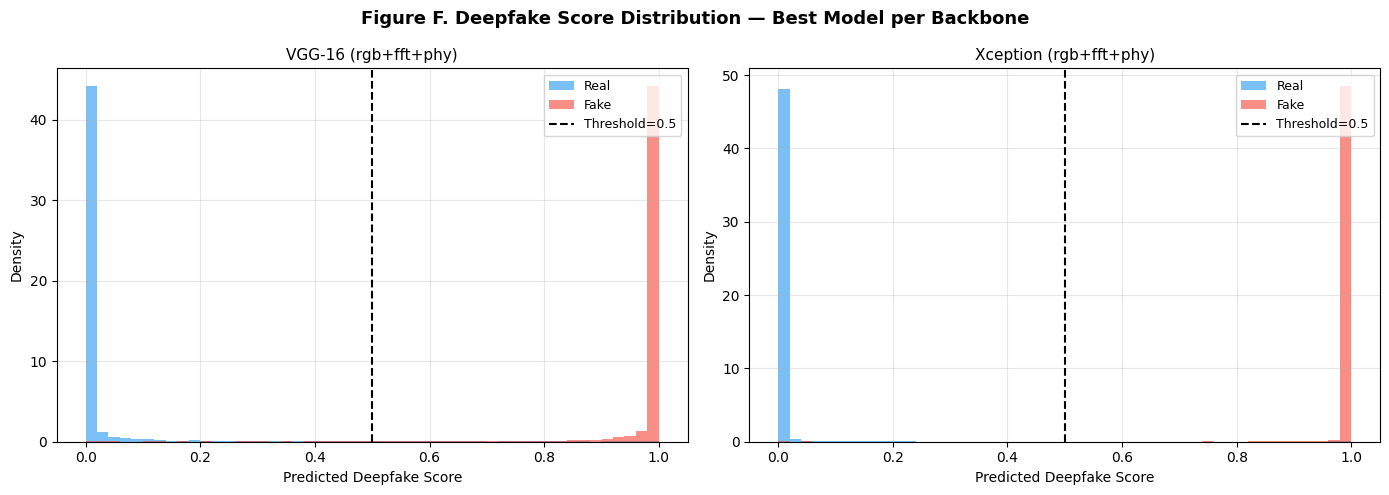

    Saved → eda_outputs/FigF_score_distribution.png
15. Gate weight analysis ...
            Model Backbone     Streams  gate_rgb  gate_fft  gate_phy
        vgg16_rgb    vgg16         rgb    0.7233       NaN       NaN
    vgg16_rgb_fft    vgg16     rgb+fft    0.7218    0.7284       NaN
vgg16_rgb_fft_phy    vgg16 rgb+fft+phy    0.7193    0.7265    0.7249
         xcep_rgb xception         rgb    0.7296       NaN       NaN
     xcep_rgb_fft xception     rgb+fft    0.7306    0.7291       NaN
 xcep_rgb_fft_phy xception rgb+fft+phy    0.7254    0.7291    0.7301

    Saved → export/gate_weights.csv
16. Figure G: Gate Weight Heatmap ...


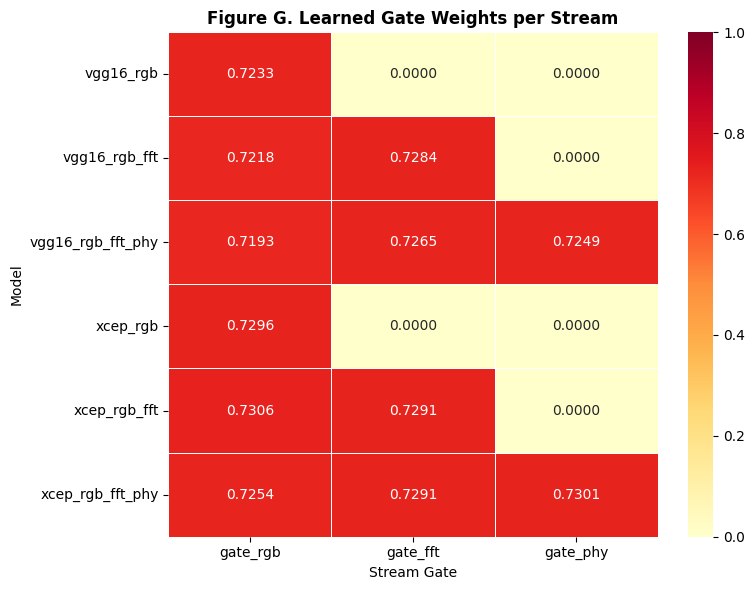

    Saved → eda_outputs/FigG_gate_weights.png

17. Final Paper-Ready Summary Table
            Model Backbone     Streams  Accuracy    AUC     AP  F1_Macro  Prec_Fake  Rec_Fake  F1_Fake
        vgg16_rgb    vgg16         rgb    0.9636 0.9954 0.9967    0.9626     0.9749    0.9623   0.9686
    vgg16_rgb_fft    vgg16     rgb+fft    0.9631 0.9955 0.9968    0.9621     0.9735    0.9629   0.9682
vgg16_rgb_fft_phy    vgg16 rgb+fft+phy    0.9799 0.9981 0.9986    0.9793     0.9833    0.9821   0.9827
         xcep_rgb xception         rgb    0.9795 0.9985 0.9990    0.9789     0.9866    0.9781   0.9823
     xcep_rgb_fft xception     rgb+fft    0.9867 0.9991 0.9993    0.9863     0.9863    0.9910   0.9886
 xcep_rgb_fft_phy xception rgb+fft+phy    0.9906 0.9995 0.9996    0.9903     0.9912    0.9927   0.9920

    Saved → export/paper_final_table.csv

18. Figure manifest ...
    FigA_roc_curves.png                             225.2 KB
    FigB_pr_curves.png                              146.1 KB
    Fig

In [1]:
# =============================================================
# Notebook Name: 04_evaluation.ipynb
# Project     : Multi-Stream Deepfake Detection (SFRPD-Net Extension)
# =============================================================

# ─────────────────────────────────────────
# 01. Environment Check
# ─────────────────────────────────────────
import sys, torch, platform

print("=" * 50)
print("01. Environment Check")
print("=" * 50)
print(f"Python  : {sys.version}")
print(f"OS      : {platform.system()} {platform.release()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print("=" * 50)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─────────────────────────────────────────
# 02. Install Required Packages
# ─────────────────────────────────────────
import subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip_install("scikit-learn")
pip_install("matplotlib")
pip_install("seaborn")
pip_install("pandas")
pip_install("timm")
pip_install("albumentations")
pip_install("torchmetrics")
print("02. Package installation complete.")


# ─────────────────────────────────────────
# 03. Import Libraries
# ─────────────────────────────────────────
import warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.metrics import (
    roc_curve, auc as sk_auc,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve,
    average_precision_score,
)

import torch
import torch.nn as nn
import torchvision.models as models
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

print("03. All libraries imported successfully.")


# ─────────────────────────────────────────
# 04. Paths & Configuration
# ─────────────────────────────────────────
IMG_SIZE   = 299
BATCH_SIZE = 32
RANDOM_SEED= 42

EXPORT_DIR  = Path("./export")
SPLIT_DIR   = Path("./processed/splits")
TRACK1_DIR  = Path("./processed/track1_face")
TRACK2_DIR  = Path("./processed/track2_fullscene")
CKPT_DIR    = Path("./checkpoints")
EDA_DIR     = Path("./eda_outputs")
EDA_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

EXPERIMENTS = [
    {"exp_name": "vgg16_rgb",         "backbone": "vgg16",
     "active_streams": ["rgb"]},
    {"exp_name": "vgg16_rgb_fft",     "backbone": "vgg16",
     "active_streams": ["rgb","fft"]},
    {"exp_name": "vgg16_rgb_fft_phy", "backbone": "vgg16",
     "active_streams": ["rgb","fft","phy"]},
    {"exp_name": "xcep_rgb",          "backbone": "xception",
     "active_streams": ["rgb"]},
    {"exp_name": "xcep_rgb_fft",      "backbone": "xception",
     "active_streams": ["rgb","fft"]},
    {"exp_name": "xcep_rgb_fft_phy",  "backbone": "xception",
     "active_streams": ["rgb","fft","phy"]},
]

print("04. Configuration set.")


# ─────────────────────────────────────────
# 05. Load Saved Prediction CSVs
# ─────────────────────────────────────────
print("05. Loading saved prediction CSVs ...")

pred_records = {}
for cfg in EXPERIMENTS:
    name = cfg["exp_name"]
    path = EXPORT_DIR / f"{name}_test_predictions.csv"
    if path.exists():
        pred_records[name] = pd.read_csv(path)
        print(f"    Loaded: {name} ({len(pred_records[name]):,} samples)")
    else:
        print(f"    [MISSING] {name} — run Notebook 03 first.")

print(f"    Total loaded: {len(pred_records)} / {len(EXPERIMENTS)} experiments")


# ─────────────────────────────────────────
# 06. Reload Best Models from Checkpoints
# ─────────────────────────────────────────
print("06. Reloading best models from checkpoints ...")

def build_backbone(backbone_name: str, out_dim: int = 256) -> nn.Module:
    if backbone_name == "vgg16":
        base = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_f = base.classifier[0].in_features
        base.classifier = nn.Sequential(
            nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, out_dim), nn.ReLU(),
        )
    elif backbone_name == "xception":
        base = timm.create_model("xception", pretrained=False, num_classes=0)
        in_f = base.num_features
        base = nn.Sequential(
            base,
            nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, out_dim), nn.ReLU(),
        )
    return base


class SFRPDNet(nn.Module):
    def __init__(self, backbone, stream_dim=256, active_streams=["rgb","fft","phy"]):
        super().__init__()
        self.active_streams = active_streams
        self.stream_dim     = stream_dim
        if "rgb" in active_streams:
            self.rgb_stream = build_backbone(backbone, stream_dim)
        if "fft" in active_streams:
            self.fft_stream = build_backbone(backbone, stream_dim)
        if "phy" in active_streams:
            self.phy_stream = build_backbone(backbone, stream_dim)
        self.gates = nn.ParameterDict({
            s: nn.Parameter(torch.ones(1)) for s in active_streams
        })
        fused_dim = stream_dim * len(active_streams)
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, batch):
        feats = []
        if "rgb" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["rgb"]) *
                         self.rgb_stream(batch["rgb"]))
        if "fft" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["fft"]) *
                         self.fft_stream(batch["fft"]))
        if "phy" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["phy"]) *
                         self.phy_stream(batch["phy"]))
        return self.classifier(torch.cat(feats, dim=1))


saved_models = {}
for cfg in EXPERIMENTS:
    name  = cfg["exp_name"]
    ckpt  = CKPT_DIR / f"{name}_best.pt"
    if not ckpt.exists():
        print(f"    [SKIP] {name} — checkpoint not found.")
        continue
    model = SFRPDNet(cfg["backbone"], active_streams=cfg["active_streams"]).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    saved_models[name] = model
    print(f"    Loaded: {name}")

print(f"    Models loaded: {len(saved_models)} / {len(EXPERIMENTS)}")


# ─────────────────────────────────────────
# 07. Dataset & DataLoader (Test Set)
# ─────────────────────────────────────────
EVAL_TRANSFORM = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class DeepfakeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        return np.array(Image.open(path).convert("RGB"))

    def _fft(self, img):
        fft_ch = []
        for c in range(3):
            ch  = img[:,:,c].astype(np.float32)
            f   = np.fft.fft2(ch)
            mag = np.log1p(np.abs(np.fft.fftshift(f)))
            mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
            fft_ch.append((mag * 255).astype(np.uint8))
        return np.stack(fft_ch, axis=-1)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row["label"], dtype=torch.long)
        t1    = self._load(row["track1_path"])
        t2    = self._load(row["track2_path"])
        rgb   = self.tf(image=t1)["image"]
        fft   = self.tf(image=self._fft(t1))["image"]
        phy   = self.tf(image=t2)["image"]
        return {"rgb": rgb, "fft": fft, "phy": phy, "label": label}

df_test     = pd.read_csv(SPLIT_DIR / "test.csv")
test_ds     = DeepfakeDataset(df_test, EVAL_TRANSFORM)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0, pin_memory=True)
print(f"07. Test DataLoader ready — {len(test_ds):,} samples")


# ─────────────────────────────────────────
# 08. Full Metrics Computation (All Models)
# ─────────────────────────────────────────
print("08. Computing full metrics for all models ...")

metrics_rows = []
for cfg in EXPERIMENTS:
    name = cfg["exp_name"]
    if name not in pred_records:
        continue
    df_p    = pred_records[name]
    y_true  = df_p["label"].values
    y_pred  = df_p["pred"].values
    y_prob  = df_p["prob_fake"].values

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = sk_auc(fpr, tpr)
    ap          = average_precision_score(y_true, y_prob)
    report      = classification_report(y_true, y_pred,
                      target_names=["Real","Fake"], output_dict=True)

    metrics_rows.append({
        "Model"     : name,
        "Backbone"  : cfg["backbone"],
        "Streams"   : "+".join(cfg["active_streams"]),
        "Accuracy"  : round(report["accuracy"], 4),
        "AUC"       : round(roc_auc, 4),
        "AP"        : round(ap, 4),
        "F1_Macro"  : round(report["macro avg"]["f1-score"], 4),
        "Prec_Fake" : round(report["Fake"]["precision"], 4),
        "Rec_Fake"  : round(report["Fake"]["recall"], 4),
        "F1_Fake"   : round(report["Fake"]["f1-score"], 4),
        "Prec_Real" : round(report["Real"]["precision"], 4),
        "Rec_Real"  : round(report["Real"]["recall"], 4),
        "F1_Real"   : round(report["Real"]["f1-score"], 4),
    })

df_metrics = pd.DataFrame(metrics_rows)
df_metrics.to_csv(EXPORT_DIR / "final_metrics_table.csv", index=False)
print(df_metrics[["Model","Accuracy","AUC","AP","F1_Macro"]].to_string(index=False))
print("\n    Saved → export/final_metrics_table.csv")


# ─────────────────────────────────────────
# 09. Figure A — ROC Curves (Publication Quality)
# ─────────────────────────────────────────
print("\n09. Figure A: ROC Curves ...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure A. ROC Curves by Backbone and Stream Configuration",
             fontsize=13, fontweight="bold")

palette_vgg  = ["#90CAF9","#1565C0","#0D47A1"]
palette_xcep = ["#A5D6A7","#2E7D32","#1B5E20"]
groups = [
    (axes[0], [e for e in EXPERIMENTS if e["backbone"]=="vgg16"],
     palette_vgg,  "VGG-16"),
    (axes[1], [e for e in EXPERIMENTS if e["backbone"]=="xception"],
     palette_xcep, "Xception"),
]

for ax, exps, palette, title in groups:
    for cfg, col in zip(exps, palette):
        name = cfg["exp_name"]
        if name not in pred_records:
            continue
        df_p        = pred_records[name]
        fpr, tpr, _ = roc_curve(df_p["label"], df_p["prob_fake"])
        roc_auc     = sk_auc(fpr, tpr)
        streams     = "+".join(cfg["active_streams"])
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f"{streams} (AUC={roc_auc:.4f})")
    ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(f"Backbone: {title}", fontsize=11)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig(EDA_DIR / "FigA_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigA_roc_curves.png")


# ─────────────────────────────────────────
# 10. Figure B — Precision-Recall Curves
# ─────────────────────────────────────────
print("10. Figure B: Precision-Recall Curves ...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure B. Precision-Recall Curves by Backbone and Stream Configuration",
             fontsize=13, fontweight="bold")

groups = [
    (axes[0], [e for e in EXPERIMENTS if e["backbone"]=="vgg16"],
     palette_vgg,  "VGG-16"),
    (axes[1], [e for e in EXPERIMENTS if e["backbone"]=="xception"],
     palette_xcep, "Xception"),
]

for ax, exps, palette, title in groups:
    for cfg, col in zip(exps, palette):
        name = cfg["exp_name"]
        if name not in pred_records:
            continue
        df_p      = pred_records[name]
        prec, rec, _ = precision_recall_curve(
            df_p["label"], df_p["prob_fake"])
        ap        = average_precision_score(df_p["label"], df_p["prob_fake"])
        streams   = "+".join(cfg["active_streams"])
        ax.plot(rec, prec, color=col, lw=2,
                label=f"{streams} (AP={ap:.4f})")
    ax.set_xlabel("Recall", fontsize=10)
    ax.set_ylabel("Precision", fontsize=10)
    ax.set_title(f"Backbone: {title}", fontsize=11)
    ax.legend(fontsize=9, loc="lower left")
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig(EDA_DIR / "FigB_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigB_pr_curves.png")


# ─────────────────────────────────────────
# 11. Figure C — Confusion Matrices (4 Best Models)
# ─────────────────────────────────────────
print("11. Figure C: Confusion Matrices ...")

best_four = [
    "vgg16_rgb_fft_phy",
    "xcep_rgb",
    "xcep_rgb_fft",
    "xcep_rgb_fft_phy",
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Figure C. Confusion Matrices — Selected Models",
             fontsize=13, fontweight="bold")

for ax, name in zip(axes, best_four):
    if name not in pred_records:
        ax.set_visible(False)
        continue
    df_p = pred_records[name]
    cm   = confusion_matrix(df_p["label"], df_p["pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name.replace("_","\n"), fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigC_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigC_confusion_matrices.png")


# ─────────────────────────────────────────
# 12. Figure D — Ablation Study Bar Chart (Paper Table)
# ─────────────────────────────────────────
print("12. Figure D: Ablation Study Bar Chart ...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure D. Ablation Study — Performance by Stream Configuration",
             fontsize=13, fontweight="bold")

metrics_plot = ["AUC", "Accuracy", "F1_Macro"]
titles       = ["AUC", "Accuracy", "F1 Macro"]
colors_vgg   = ["#90CAF9","#1565C0","#0D47A1"]
colors_xcep  = ["#A5D6A7","#2E7D32","#1B5E20"]

x       = np.arange(3)   # 3 stream configs
width   = 0.35
streams = ["rgb", "rgb+fft", "rgb+fft+phy"]

for ax, metric, title in zip(axes, metrics_plot, titles):
    vgg_vals  = df_metrics[df_metrics["Backbone"]=="vgg16"][metric].values
    xcep_vals = df_metrics[df_metrics["Backbone"]=="xception"][metric].values

    b1 = ax.bar(x - width/2, vgg_vals,  width, label="VGG-16",
                color="#1565C0", edgecolor="white", alpha=0.85)
    b2 = ax.bar(x + width/2, xcep_vals, width, label="Xception",
                color="#2E7D32", edgecolor="white", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(streams, fontsize=9)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0.94, 1.005)
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0005,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigD_ablation_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigD_ablation_bar.png")


# ─────────────────────────────────────────
# 13. Figure E — Training Curves (Best Model)
# ─────────────────────────────────────────
print("13. Figure E: Training Curves for Best Model ...")

best_name = "xcep_rgb_fft_phy"
hist_path = Path("./logs") / f"{best_name}_history.csv"

if hist_path.exists():
    df_h = pd.read_csv(hist_path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Figure E. Training Curves — {best_name}",
                 fontsize=13, fontweight="bold")

    axes[0].plot(df_h["epoch"], df_h["tr_loss"],
                 "b-o", ms=4, label="Train Loss")
    axes[0].plot(df_h["epoch"], df_h["vl_loss"],
                 "r-o", ms=4, label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

    axes[1].plot(df_h["epoch"], df_h["tr_acc"],
                 "b-o", ms=4, label="Train Acc")
    axes[1].plot(df_h["epoch"], df_h["vl_acc"],
                 "r-o", ms=4, label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].legend()
    axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)

    axes[2].plot(df_h["epoch"], df_h["vl_auc"],
                 "g-o", ms=4, label="Val AUC")
    axes[2].set_title("Validation AUC"); axes[2].legend()
    axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(EDA_DIR / "FigE_training_curves_best.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print("    Saved → eda_outputs/FigE_training_curves_best.png")
else:
    print(f"    [SKIP] {hist_path} not found.")


# ─────────────────────────────────────────
# 14. Figure F — Score Distribution (Real vs Fake)
# ─────────────────────────────────────────
print("14. Figure F: Score Distribution ...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure F. Deepfake Score Distribution — Best Model per Backbone",
             fontsize=13, fontweight="bold")

for ax, name, title in [
    (axes[0], "vgg16_rgb_fft_phy", "VGG-16 (rgb+fft+phy)"),
    (axes[1], "xcep_rgb_fft_phy",  "Xception (rgb+fft+phy)"),
]:
    if name not in pred_records:
        ax.set_visible(False)
        continue
    df_p = pred_records[name]
    ax.hist(df_p[df_p["label"]==0]["prob_fake"],
            bins=50, alpha=0.6, color="#2196F3",
            label="Real", density=True)
    ax.hist(df_p[df_p["label"]==1]["prob_fake"],
            bins=50, alpha=0.6, color="#F44336",
            label="Fake", density=True)
    ax.axvline(0.5, color="black", lw=1.5, linestyle="--", label="Threshold=0.5")
    ax.set_xlabel("Predicted Deepfake Score", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigF_score_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigF_score_distribution.png")


# ─────────────────────────────────────────
# 15. Gate Weight Analysis (Stream Contribution)
# ─────────────────────────────────────────
print("15. Gate weight analysis ...")

gate_rows = []
for cfg in EXPERIMENTS:
    name = cfg["exp_name"]
    if name not in saved_models:
        continue
    model = saved_models[name]
    row   = {"Model": name, "Backbone": cfg["backbone"],
             "Streams": "+".join(cfg["active_streams"])}
    for s in cfg["active_streams"]:
        w = torch.sigmoid(model.gates[s]).item()
        row[f"gate_{s}"] = round(w, 4)
    gate_rows.append(row)

df_gates = pd.DataFrame(gate_rows)
df_gates.to_csv(EXPORT_DIR / "gate_weights.csv", index=False)
print(df_gates.to_string(index=False))
print("\n    Saved → export/gate_weights.csv")


# ─────────────────────────────────────────
# 16. Figure G — Gate Weight Heatmap
# ─────────────────────────────────────────
print("16. Figure G: Gate Weight Heatmap ...")

gate_cols = [c for c in df_gates.columns if c.startswith("gate_")]
if gate_cols:
    gate_matrix = df_gates.set_index("Model")[gate_cols].fillna(0)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(gate_matrix, annot=True, fmt=".4f",
                cmap="YlOrRd", linewidths=0.5,
                ax=ax, vmin=0, vmax=1)
    ax.set_title("Figure G. Learned Gate Weights per Stream",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Stream Gate")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.savefig(EDA_DIR / "FigG_gate_weights.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print("    Saved → eda_outputs/FigG_gate_weights.png")


# ─────────────────────────────────────────
# 17. Final Paper-Ready Summary Table
# ─────────────────────────────────────────
print("\n" + "=" * 70)
print("17. Final Paper-Ready Summary Table")
print("=" * 70)

paper_cols = ["Model","Backbone","Streams",
              "Accuracy","AUC","AP","F1_Macro",
              "Prec_Fake","Rec_Fake","F1_Fake"]
print(df_metrics[paper_cols].to_string(index=False))
df_metrics[paper_cols].to_csv(
    EXPORT_DIR / "paper_final_table.csv", index=False)
print("\n    Saved → export/paper_final_table.csv")


# ─────────────────────────────────────────
# 18. Export Figure Manifest
# ─────────────────────────────────────────
print("\n18. Figure manifest ...")

fig_files = sorted(EDA_DIR.glob("Fig*.png"))
for f in fig_files:
    size_kb = f.stat().st_size / 1024
    print(f"    {f.name:45s} {size_kb:7.1f} KB")

pd.DataFrame([{
    "file"   : f.name,
    "size_KB": round(f.stat().st_size/1024, 1)
} for f in fig_files]).to_csv(
    EXPORT_DIR / "figure_manifest.csv", index=False)
print("    Saved → export/figure_manifest.csv")

print("\n" + "=" * 60)
print("ALL EVALUATION COMPLETE.")
print("=" * 60)
print("\nNotebook 04 complete.")
print("Outputs ready for paper submission:")
print("  - export/paper_final_table.csv   ← Main results table")
print("  - export/gate_weights.csv        ← Stream contribution analysis")
print("  - eda_outputs/FigA_roc_curves.png")
print("  - eda_outputs/FigB_pr_curves.png")
print("  - eda_outputs/FigC_confusion_matrices.png")
print("  - eda_outputs/FigD_ablation_bar.png")
print("  - eda_outputs/FigE_training_curves_best.png")
print("  - eda_outputs/FigF_score_distribution.png")
print("  - eda_outputs/FigG_gate_weights.png")